In [1]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from collections import Counter


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]


In [ ]:
def load_common_data(folder_path, min_files=10, encoding="latin1", print_progress=False):
    file_columns = {}

    # --- Step 1: Read headers safely ---
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            path = os.path.join(folder_path, file)
            try:
                df = pd.read_csv(path, nrows=0, encoding=encoding)
                file_columns[file] = set(df.columns)
            except Exception as e:
                print(f"⚠ Skipping {file} during scan: {e}")

    if len(file_columns) < min_files:
        raise ValueError(f"Not enough readable files. Found {len(file_columns)}")

    # --- Step 2: Start with file that has the most columns ---
    sorted_files = sorted(file_columns.items(), key=lambda x: len(x[1]), reverse=True)

    selected_files = [sorted_files[0][0]]
    current_common = set(sorted_files[0][1])

    if print_progress:
        print(f"\n Starting with: {os.path.splitext(selected_files[0])[0]} ({len(current_common)} cols)")

    remaining_files = {f: cols for f, cols in sorted_files[1:]}

    # --- Step 3: Greedily add files that maximize remaining common columns ---
    while len(selected_files) < min_files and remaining_files:
        best_file = None
        best_intersection = set()

        for f, cols in remaining_files.items():
            intersection = current_common.intersection(cols)

            if len(intersection) > len(best_intersection):
                best_file = f
                best_intersection = intersection

        if best_file is None or len(best_intersection) == 0:
            print("⚠ No more compatible files can be added without losing all columns.")
            break

        selected_files.append(best_file)
        current_common = best_intersection

        if print_progress:
            print(f" + Added: {os.path.splitext(best_file)[0]} → {len(current_common)} common cols")

        del remaining_files[best_file]

    # --- Final report ---
    if print_progress:
        print(f"\n Final selected {len(selected_files)} files:")
    for f in selected_files:
        if print_progress:
            print(f" - {os.path.splitext(f)[0]} ({len(file_columns[f])} cols)")

    if print_progress:
        print(f"\n Final shared columns: {len(current_common)}")
        print(sorted(current_common))

    # --- Step 4: Load data ---
    dataframes = []

    for file in selected_files:
        path = os.path.join(folder_path, file)
        try:
            df = pd.read_csv(path, usecols=lambda c: c in current_common, encoding=encoding)

            season = os.path.splitext(file)[0]
            df["Season"] = season

            dataframes.append(df)
        except Exception as e:
            print(f"⚠ Skipping {file} during load: {e}")

    final_df = pd.concat(dataframes, ignore_index=True)

    return final_df, selected_files, list(current_common)

/var/folders/xd/8bcf5_6s4n7dsnwblqcqlthw0000gn/T/ipykernel_67278/1591882967.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Season"] = season


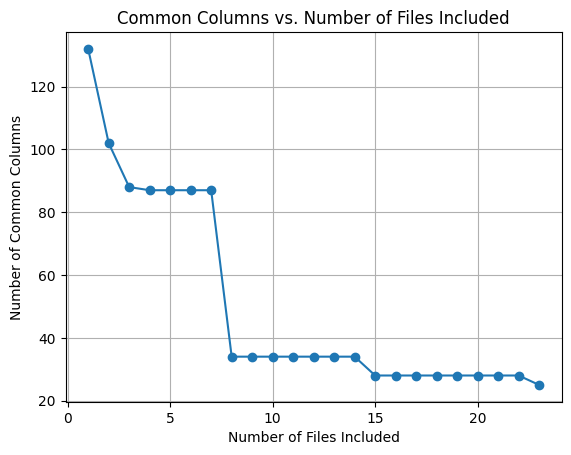

In [3]:
dataPath = "Data"
final_df, num_cols = [], []
for i in range(1, 24):
    df, _, cols = load_common_data(dataPath, min_files=i)
    final_df.append(df)
    num_cols.append(len(cols))    
plt.plot(range(1, 24), num_cols, marker='o')
plt.xlabel('Number of Files Included')
plt.ylabel('Number of Common Columns')
plt.title('Common Columns vs. Number of Files Included')
plt.grid()
plt.show()



## Multi-Season Dataset Construction (Greedy Alignment)

A greedy approach was used to build a consistent dataset across multiple football seasons.

The process starts with the season containing the most columns, then iteratively adds seasons that preserve the largest possible overlap of shared columns. At each step, the set of common columns is updated to ensure all selected seasons remain compatible.

After selecting the final group of seasons, only the columns shared across all of them are kept, and each season is loaded into a single combined DataFrame.

This ensures a consistent feature set across seasons while maximizing the number of usable datasets included.

We have chosen to include 7 seasons in our our pattern mining analysis, which provides a good balance between data richness and consistency.

In [4]:
data, selected_files, common_cols = load_common_data(dataPath, min_files=7)
print(f"Selected files: {sorted(selected_files)}")
print(f"Number of common columns: {len(common_cols)}")
# Pretty print the common columns
print("Common columns:")
for col in sorted(common_cols):
    print(f" - {col}")
print(common_cols)    

Selected files: ['20192020premierleague.csv', '20202021premierleague.csv', '20212022premierleague.csv', '20222023premierleague.csv', '20232024premierleague.csv', '20242025premierleague.csv', '20252026premierleague.csv']
Number of common columns: 87
Common columns:
 - AC
 - AF
 - AHCh
 - AHh
 - AR
 - AS
 - AST
 - AY
 - Avg<2.5
 - Avg>2.5
 - AvgA
 - AvgAHA
 - AvgAHH
 - AvgC<2.5
 - AvgC>2.5
 - AvgCA
 - AvgCAHA
 - AvgCAHH
 - AvgCD
 - AvgCH
 - AvgD
 - AvgH
 - AwayTeam
 - B365<2.5
 - B365>2.5
 - B365A
 - B365AHA
 - B365AHH
 - B365C<2.5
 - B365C>2.5
 - B365CA
 - B365CAHA
 - B365CAHH
 - B365CD
 - B365CH
 - B365D
 - B365H
 - BWA
 - BWCA
 - BWCD
 - BWCH
 - BWD
 - BWH
 - Date
 - FTAG
 - FTHG
 - FTR
 - HC
 - HF
 - HR
 - HS
 - HST
 - HTAG
 - HTHG
 - HTR
 - HY
 - HomeTeam
 - Max<2.5
 - Max>2.5
 - MaxA
 - MaxAHA
 - MaxAHH
 - MaxC<2.5
 - MaxC>2.5
 - MaxCA
 - MaxCAHA
 - MaxCAHH
 - MaxCD
 - MaxCH
 - MaxD
 - MaxH
 - P<2.5
 - P>2.5
 - PAHA
 - PAHH
 - PC<2.5
 - PC>2.5
 - PCAHA
 - PCAHH
 - PSA
 - PSCA
 - PS

In [5]:
list_of_bookmakers = ['1XB', 'B365', 'BF', 'BFD', 'BMGM', 'BV', 'BS', 'BW',
                      'CL', 'GB', 'IW', 'LB', 'PS', 'SO', 'SB', 'SJ', 'SY', 'VC', 'WH']

# assuming df is your final dataframe
cols = common_cols

present_bookmakers = set()

for b in list_of_bookmakers:
    if any(col.startswith(b) for col in cols):
        present_bookmakers.add(b)

print("Present bookmakers:", sorted(present_bookmakers))
print("Count:", len(present_bookmakers))


Present bookmakers: ['B365', 'BW', 'PS']
Count: 3


In [17]:
#relevant_cols = [c for c in common_cols if c.startswith("B365") or c.startswith("BW") or c.startswith("PS")]
prefixes = ["B365", "BW", "PS"]
suffixes = ["A", "H", "D"]

valid_cols = {p + s for p in prefixes for s in suffixes}
print(type(common_cols))

relevant_cols = [c for c in common_cols if c in valid_cols] + ['Referee']

print(f"Relevant columns include: {relevant_cols}\nnumber of columns: {len(relevant_cols)}")
common_cols

<class 'list'>
Relevant columns include: ['PSH', 'BWD', 'PSA', 'B365A', 'BWH', 'B365H', 'B365D', 'BWA', 'PSD', 'Referee']
number of columns: 10


['PSH',
 'Referee',
 'AR',
 'AC',
 'PAHA',
 'P>2.5',
 'B365CA',
 'BWD',
 'PCAHA',
 'PSA',
 'FTR',
 'HTAG',
 'MaxA',
 'MaxAHH',
 'MaxCA',
 'BWCH',
 'MaxCAHA',
 'MaxAHA',
 'HS',
 'PCAHH',
 'HF',
 'B365CAHA',
 'AS',
 'AY',
 'B365A',
 'AvgCA',
 'MaxH',
 'B365CAHH',
 'AvgCD',
 'MaxCD',
 'AvgD',
 'MaxD',
 'PSCA',
 'PSCH',
 'Time',
 'AvgCAHA',
 'BWH',
 'AvgA',
 'AvgC>2.5',
 'AvgAHH',
 'AvgCAHH',
 'AvgH',
 'B365CD',
 'B365H',
 'P<2.5',
 'AST',
 'HR',
 'HC',
 'AvgAHA',
 'B365C<2.5',
 'B365C>2.5',
 'Max>2.5',
 'MaxC>2.5',
 'MaxC<2.5',
 'HTR',
 'AHCh',
 'B365D',
 'FTAG',
 'HomeTeam',
 'BWCA',
 'PAHH',
 'B365>2.5',
 'BWA',
 'Avg>2.5',
 'PC<2.5',
 'AHh',
 'MaxCH',
 'B365AHA',
 'MaxCAHH',
 'B365CH',
 'HTHG',
 'B365<2.5',
 'AvgC<2.5',
 'HY',
 'AwayTeam',
 'B365AHH',
 'PC>2.5',
 'HST',
 'PSD',
 'FTHG',
 'AvgCH',
 'AF',
 'PSCD',
 'Date',
 'Avg<2.5',
 'BWCD',
 'Max<2.5']

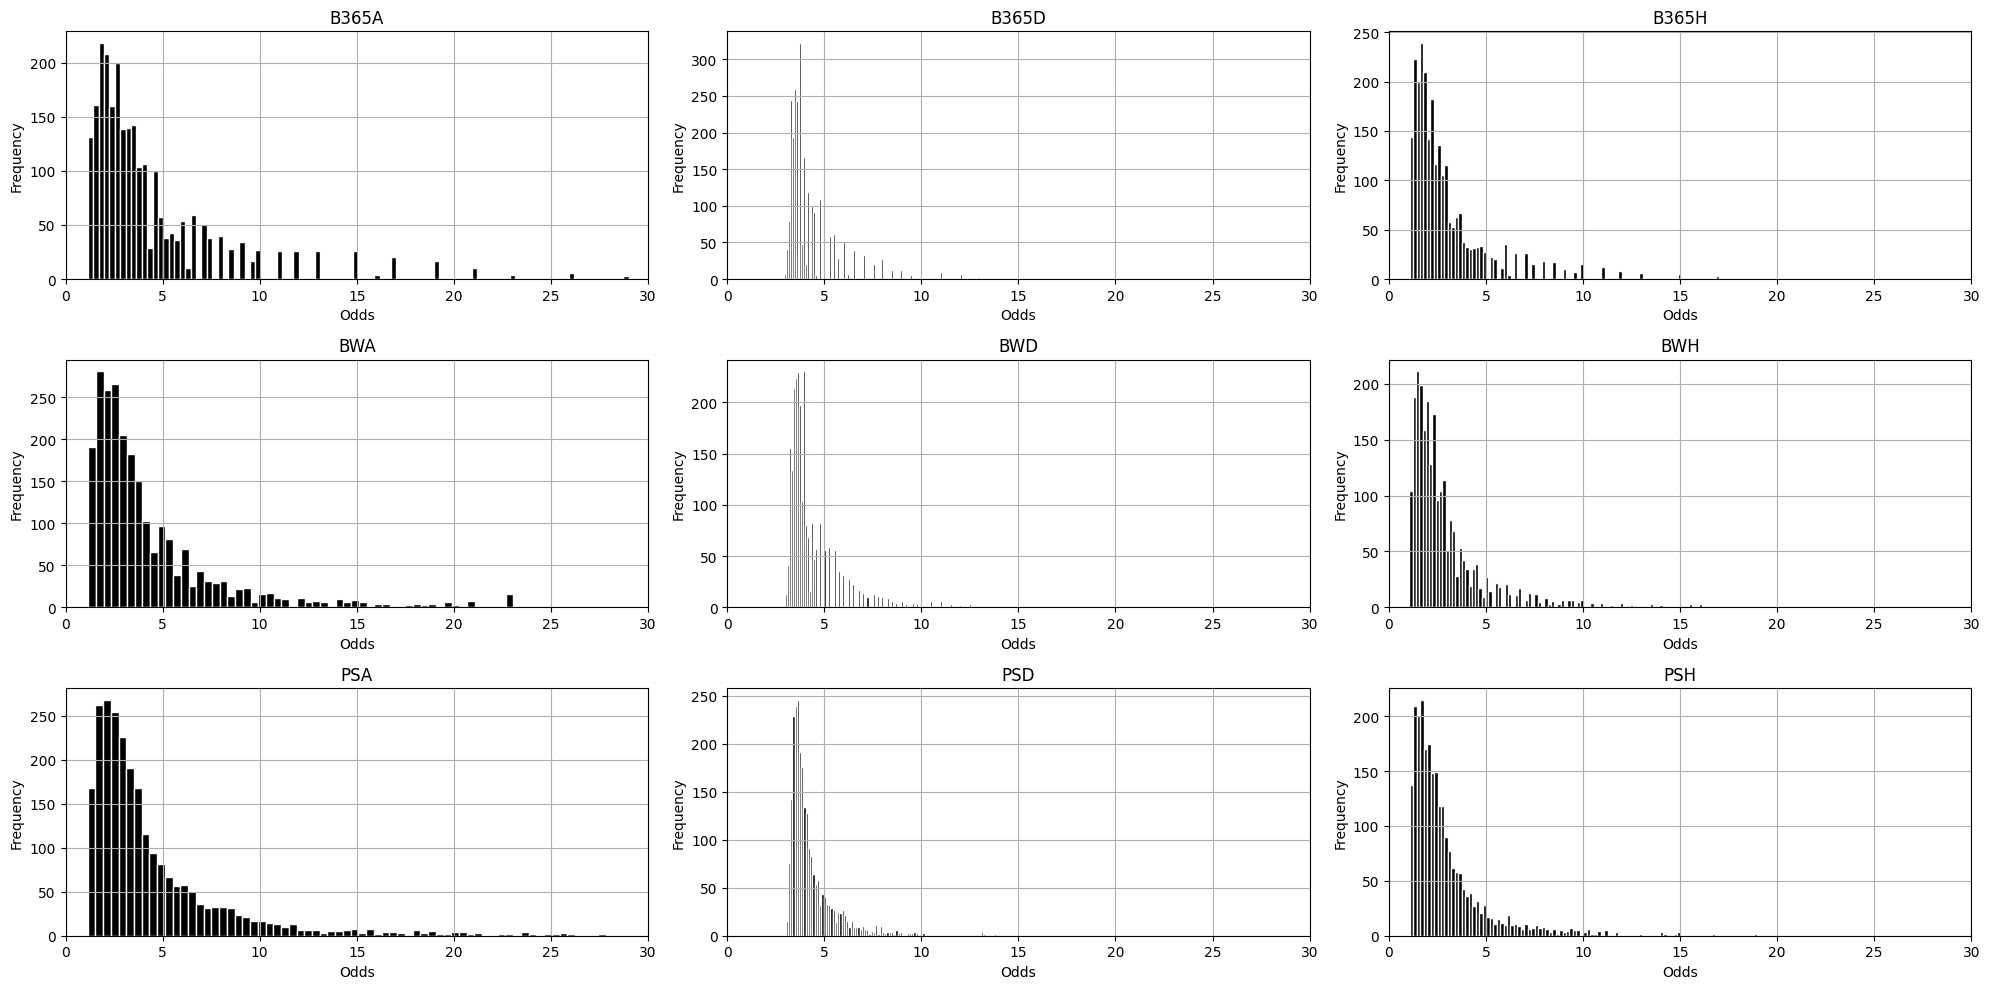

In [7]:
fig, ax = plt.subplots(3, 3, figsize=(20, 10))
ax = ax.flatten()

for i, c in enumerate(sorted(relevant_cols)):
    if i >= len(ax):  # safety in case more columns than plots
        break

    data_col = data[c].dropna()

    ax[i].hist(data_col, bins=100, edgecolor='white', color='k')
    ax[i].set_title(f"{c}")
    ax[i].set_xlabel("Odds")
    ax[i].set_ylabel("Frequency")
    # -- log scale for better visibility of low-frequency bins --
    #ax[i].set_yscale('log')
    ax[i].set_xlim(0, 30)
    ax[i].grid(True)

# hide unused subplots (if any)
for j in range(i + 1, len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

Based on the distributions above we notice that it may not make sense to use the same discretization for all columns, as the 'draw' distributions differ significantly from the 'home win' and 'away win' distributions. We will therefore use different discretization bins.

In [3]:
def compute_quantile_bins(data, relevant_cols, suffixes=["H", "D", "A"], n_bins=5):
    """
    Compute quantile-based bin edges for each outcome type (H, D, A),
    pooling odds across all bookmakers for that outcome type.
    
    Returns a dict like: {'H': (bins, labels), 'D': (bins, labels), 'A': (bins, labels)}
    """
    bin_specs = {}
    
    for suffix in suffixes:
        # Pool all odds for this outcome across all bookmakers
        cols_for_suffix = [c for c in relevant_cols if c.endswith(suffix)]
        pooled = pd.concat([data[c].dropna() for c in cols_for_suffix])
        
        # Compute quantile edges (0%, 20%, 40%, 60%, 80%, 100%)
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = pooled.quantile(quantiles).values
        
        # Ensure strictly increasing edges (can have ties at extremes)
        edges = np.unique(edges)
        edges[0] = 0       # open lower bound
        edges[-1] = np.inf # open upper bound
        
        # Labels like "1.42–1.75", "1.75–2.10", etc.
        labels = [
            f"{edges[i]:.2f}–{edges[i+1]:.2f}".replace("inf", "∞")
            for i in range(len(edges) - 1)
        ]
        
        bin_specs[suffix] = (edges, labels)
        print(f"[{suffix}] edges: {np.round(edges, 3)}  →  {len(labels)} bins")
    
    return bin_specs


def discretize_odds_quantile(series, bin_specs):
    """
    Discretize a single odds column using precomputed quantile bin specs.
    Detects outcome type from the column name's last character.
    """
    suffix = series.name[-1]  # 'H', 'D', or 'A'
    bins, labels = bin_specs[suffix]
    return pd.cut(series, bins=bins, labels=labels)
# Step 1: Compute shared bins per outcome type, pooled across bookmakers
bin_specs = compute_quantile_bins(data, relevant_cols)

# Step 2: Apply to each column
discrete_data = data.copy()
for c in relevant_cols:
    if c[-1] in bin_specs:
        discrete_data[c] = discretize_odds_quantile(discrete_data[c], bin_specs)
    # else: non-odds cols like 'Referee' are left as-is

discrete_data[relevant_cols].head()

NameError: name 'data' is not defined

In [4]:
for suffix in ["H", "D", "A"]:
    sample_col = next(c for c in relevant_cols if c.endswith(suffix))
    print(f"\n{sample_col} bin distribution (%):")
    print((discrete_data[sample_col].value_counts(normalize=True) * 100).sort_index().round(1))

NameError: name 'relevant_cols' is not defined

In [5]:
def make_transactions(df, cols):
    T = []

    for _, row in df[cols].iterrows():
        items = []

        for c in cols:
            val = row[c]
            if pd.notna(val):
                items.append(f"{c}={val}")

        T.append(items)

    return T
T = make_transactions(discrete_data, relevant_cols)

rule  = lambda lhs, rhs: "%s => %s" % (str(lhs), str(rhs)) # For generating rule strings
from itertools import combinations, chain


def compute_support(Ck: list, T: list, still_applicable=None):
    """
    Function that computes the support of each candidate itemset in Ck with respect to the transactions in T.
    Parameters:
        Ck: list of candidate itemsets of size k
        T: list of transactions (each transaction is a list of items)
        still_applicable: a list of boolean values indicating whether each transaction is applicable
    Returns:
        counts: a list of counts corresponding to the support of each candidate itemset in Ck
    """
    if still_applicable is None:
        still_applicable = [True] * len(T)
        
    counts = {} # Dictionary to store counts of each candidate itemset slide 40
    for row, t in enumerate(T):
        if not still_applicable[row]: continue
        found_any = False
        for c in Ck:
            if set.issubset(set(c), t):
                if c in counts:
                    counts[c] += 1
                else:
                    counts[c] = 1
                found_any = True
        still_applicable[row] = found_any
    return counts

def extend_prefix_tree(Ck_prev):
    """
    Function that extends the prefix tree by generating new candidate itemsets of size k+1 from the previous candidate itemsets of size k.
    Parameters:
        Ck_prev: list of candidate itemsets of size k
    Returns:
        Ck: list of candidate itemsets of size k+1
    """
    Ck = set() 
    #join step
    for itemset in Ck_prev:
        its1 = tuple(sorted(itemset))
        for itemset2 in Ck_prev:
            its2 = tuple(sorted(itemset2))
            if its1[:-1] == its2[:-1] and its1 < its2: Ck.add(its1 + its2[-1:]) # Join step: if the first k-1 items are the same and the last item is different, we can join them
    #prune step
    to_remove = set()
    for c in Ck:
        for subset in combinations(c, len(c) - 1):
            if subset not in Ck_prev:
                to_remove.add(c)
                break            
    for c in to_remove:
        Ck.remove(c)
    return Ck

def powerset(iterable):
    """
    Function that generates the powerset of a given iterable.
    Parameters: 
            iterable: an iterable (e.g., list, set, etc.) for which to generate the powerset
    Returns:
            A list of all subsets of the input iterable      
    """
    s = list(iterable)
    out = chain.from_iterable(combinations(s, r) for r in range(1, len(s))) # Generate all non-empty subsets
    return out

def is_relevant(A, B):
    def parse(item):
        col, val = item.split("=")
        bookmaker = col[:-1]
        outcome = col[-1]
        value = val.replace(" ", "")
        return bookmaker, outcome, value

    A_parsed = [parse(x) for x in A]
    B_parsed = [parse(x) for x in B]

    all_parsed = A_parsed + B_parsed

    # 1. ❌ NEW: reject if rule involves all three outcomes (A, H, D)
    outcomes = {o for _, o, _ in all_parsed}
    if outcomes == {"A", "H", "D"}:
        return False

    # 2. ❌ Remove exact duplicate signals across sides
    A_set = set(A_parsed)
    B_set = set(B_parsed)
    if A_set & B_set:
        return False

    # 3. ❌ Remove same-market duplication across bookmakers
    A_market = {(o, v) for _, o, v in A_parsed}
    B_market = {(o, v) for _, o, v in B_parsed}
    if A_market & B_market:
        return False

    return True

def apriori_algorithm(T, support=0.05, min_confidence=0.7):
    """
        Apriori algorithm for mining association rules.
        Inputs:
            T:               A list of lists, each inner list will contiain integer-item-ids. 
                             Example: T = [[1, 2, 5], [2, 3, 4], [1, 6]]
            support:         The proportion of occurences needed to keep itemsets.
            min_confidence:  Minimum confidence for the algorithm to output the rule.
    """        
    rules = []
    # --- Generate frequent itemsets using the Apriori algorithm ---
    N = len(T) # Total number of transactions
    # Construct the initial candidate itemsets of size 1
    items = set(i for t in T for i in t) # Get all unique items in the transactions
    C1 = set((i,) for i in items) # Convert to set of tuples for consistency with later itemsets
    counts = compute_support(C1, T) # Compute support for itemsets of size 1
    L1 = [c for c in counts if counts[c] / N >= support] # Filter itemsets by support
    L = [L1]
    support_dict = {c: counts[c] / N for c in L1} # Store support values for itemsets of size 1
    # Second step
    k = 2
    while L[k-2]: # While there are itemsets of size k-1
        Ck = extend_prefix_tree(L[k-2]) # Generate candidate itemsets of size k
        print(k)
        if not Ck: break # If no candidates, stop

        counts = compute_support(Ck, T) # Compute support for itemsets of size k
        Lk = []
        for i in Ck:
            supp = counts.get(i, 0) / N # Get support for itemset i, default to 0 if not found
            if supp >= support:
                Lk.append(i) # Keep itemsets that meet the support threshold
                support_dict[i] = supp # Store support value for itemset i
        if not Lk: break # If no itemsets meet the support threshold, stop
        L.append(Lk) # Add the frequent itemsets of size k to the list
        k += 1    
    # --- Generate rules from the frequent itemsets ---  
    for Lk in L:
        for itemset in Lk:
            if len(itemset) < 2: continue # We need at least 2 items to form a rule

            for A in powerset(itemset):
                B = tuple(sorted(set(itemset) - set(A))) # Get the remaining items as B
                if not B: continue # Skip if B is empty

                if not is_relevant(A, B):
                    continue

                conf = support_dict[itemset] / support_dict[A] # Calculate confidence of the rule A => B
                if conf >= min_confidence:
                    rules.append((rule(A, B), conf)) # Store the rule along with its confidence
    return rules
support = 0.1
min_confidence = 0.75                
rules = apriori_algorithm(T, support=support, min_confidence=min_confidence)
print(f"Generated {len(rules)} rules with support >= {support} and confidence >= {min_confidence}")
print("Sample rules:")
rules

NameError: name 'discrete_data' is not defined